# Learning the Best Diabetes Medication

A doctor must find which drug best reduces a patient's blood sugar (A1c). Each prescription yields a noisy observation — the measured outcome varies around the drug's true effect. This is a multi-armed bandit problem where the doctor must balance exploiting the current best drug against exploring alternatives.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42) 
plt.rcParams['figure.figsize'] = (12, 6)  


## Problem Data

Five drug candidates with population-level statistics from Table 4.1. These serve as the prior belief $(\bar{\mu}_x^0, \bar{\sigma}_x^0)$ for each drug — the starting point before any patient-specific observation.

| Drug | $\bar{\mu}_x^0$ | $\bar{\sigma}_x^0$ |
|---|---|---|
| Metformin | 0.32 | 0.12 |
| Sensitizers | 0.28 | 0.09 |
| Secretagogues | 0.30 | 0.17 |
| Alpha-glucosidase Inh. | 0.26 | 0.15 |
| Peptide Analogs | 0.21 | 0.11 |

In [19]:
drug_names = ['Metformin', 'Sensitizers', 'Secretagogues',
              'Alpha-glucosidase Inh.', 'Peptide Analogs']

# médias e desvios da priori populacional — retirados da Tabela 4.1
mu_prior = np.array([0.32, 0.28, 0.30, 0.26, 0.21])
sigma_prior = np.array([0.12, 0.09, 0.17, 0.15, 0.11])
n_drugs = len(drug_names)

for i in range(n_drugs):
    print(f"{drug_names[i]:25s}  μ₀ = {mu_prior[i]:.2f},  σ₀ = {sigma_prior[i]:.2f}")


Metformin                  μ₀ = 0.32,  σ₀ = 0.12
Sensitizers                μ₀ = 0.28,  σ₀ = 0.09
Secretagogues              μ₀ = 0.30,  σ₀ = 0.17
Alpha-glucosidase Inh.     μ₀ = 0.26,  σ₀ = 0.15
Peptide Analogs            μ₀ = 0.21,  σ₀ = 0.11


## Prior Distributions

Each drug's unknown true effect is modeled as $\mu_x \sim \mathcal{N}(\bar{\mu}_x^0, (\bar{\sigma}_x^0)^2)$. Wider distributions indicate more uncertainty.

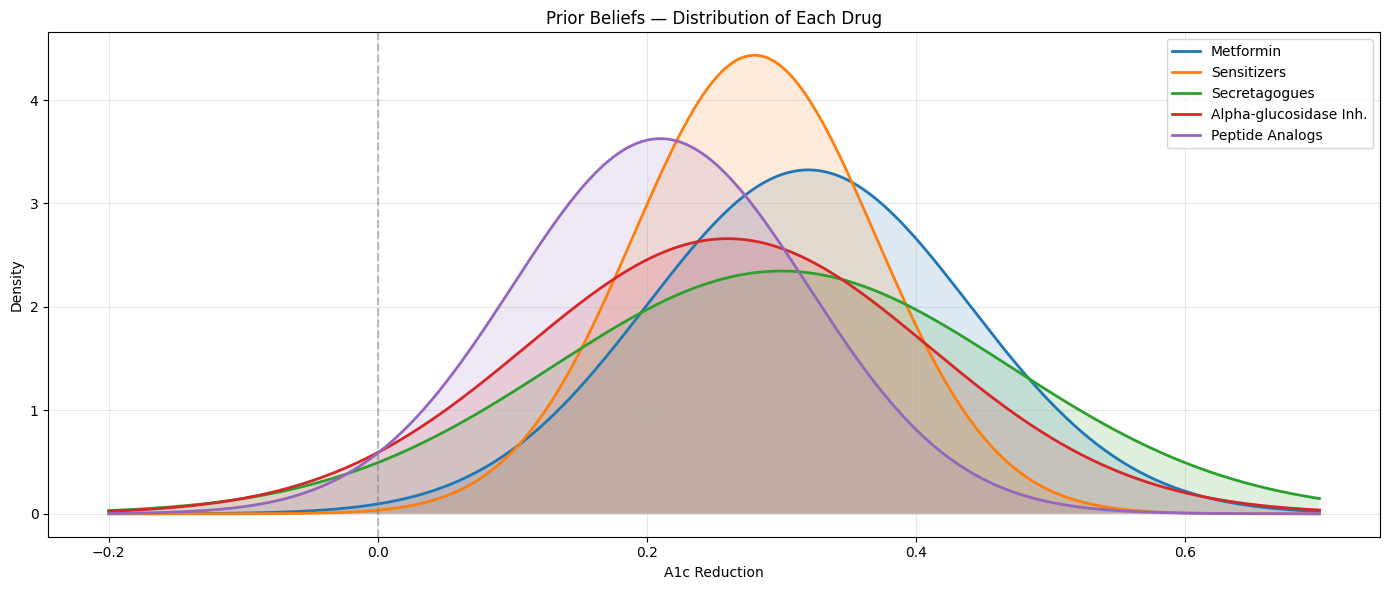

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
x_range = np.linspace(-0.2, 0.7, 500)  # intervalo de valores de redução de A1c a plotar

for i in range(n_drugs):
    y = norm.pdf(x_range, mu_prior[i], sigma_prior[i])  # densidade gaussiana de cada droga
    ax.plot(x_range, y, label=drug_names[i], linewidth=2)
    ax.fill_between(x_range, y, alpha=0.15)  # área sombreada embaixo da curva para facilitar leitura

ax.set(xlabel='A1c Reduction', ylabel='Density',
       title='Prior Beliefs — Distribution of Each Drug')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)  # referência: redução zero
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


## Bayesian Belief State

The state $S^n = (\bar{\mu}_x^n, \beta_x^n)_{x \in \mathcal{X}}$ tracks, after $n$ experiments:

- $\bar{\mu}_x^n$: current estimate of drug $x$'s mean effect
- $\beta_x^n = 1/(\bar{\sigma}_x^n)^2$: precision (higher = more confident)

When drug $x^n$ is tested, we observe $W^{n+1} = \mu_{x^n} + \varepsilon^{n+1}$ with $\varepsilon^{n+1} \sim \mathcal{N}(0, (\sigma^W)^2)$.

In [21]:
class BayesianBeliefState:
    """State S^n = (μ̄ⁿ_x, βⁿ_x) for all drugs."""

    def __init__(self, mu_prior, sigma_prior, sigma_W):
        self.n_drugs = len(mu_prior)
        self.mu = mu_prior.copy()              # média atual da crença sobre cada droga
        self.beta = 1.0 / (sigma_prior ** 2)  # precisão = 1/σ² (quanto confiamos na estimativa)
        self.beta_W = 1.0 / (sigma_W ** 2)   # precisão do instrumento de medição
        self.N_x = np.zeros(self.n_drugs, dtype=int)  # contador de testes por droga
        self.n_experiments = 0                # total de experimentos realizados até agora

    @property
    def sigma(self):
        return 1.0 / np.sqrt(self.beta)  # converte precisão de volta para desvio padrão

    def update(self, x, W):
        """Eqs. 4.1-4.2: Bayesian update after observing W for drug x."""
        # nova média é a média ponderada pela precisão entre crença atual e observação
        self.mu[x] = (self.beta[x] * self.mu[x] + self.beta_W * W) / (self.beta[x] + self.beta_W)
        self.beta[x] += self.beta_W  # precisão sempre cresce — nunca perdemos informação
        self.N_x[x] += 1
        self.n_experiments += 1

    def copy(self):
        # cópia profunda do estado — necessária para não alterar o original em simulações
        new = BayesianBeliefState.__new__(BayesianBeliefState)
        new.n_drugs = self.n_drugs
        new.mu = self.mu.copy()
        new.beta = self.beta.copy()
        new.beta_W = self.beta_W
        new.N_x = self.N_x.copy()
        new.n_experiments = self.n_experiments
        return new


sigma_W = 0.05  # ruído da observação — pequeno, mas presente
state = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)

print(f"{'Drug':25s} {'μ₀':>8s} {'σ₀':>8s} {'β₀':>10s}")
print("-" * 55)
for i in range(n_drugs):
    print(f"{drug_names[i]:25s} {state.mu[i]:8.4f} {state.sigma[i]:8.4f} {state.beta[i]:10.2f}")


Drug                            μ₀       σ₀         β₀
-------------------------------------------------------
Metformin                   0.3200   0.1200      69.44
Sensitizers                 0.2800   0.0900     123.46
Secretagogues               0.3000   0.1700      34.60
Alpha-glucosidase Inh.      0.2600   0.1500      44.44
Peptide Analogs             0.2100   0.1100      82.64


## Bayesian Update in Action

The update equations:

$$\bar{\mu}_x^{n+1} = \frac{\beta_x^n \cdot \bar{\mu}_x^n + \beta^W \cdot W^{n+1}}{\beta_x^n + \beta^W}, \qquad \beta_x^{n+1} = \beta_x^n + \beta^W$$

The new mean is a precision-weighted average between prior and observation. Precision always increases — each observation tightens the belief.

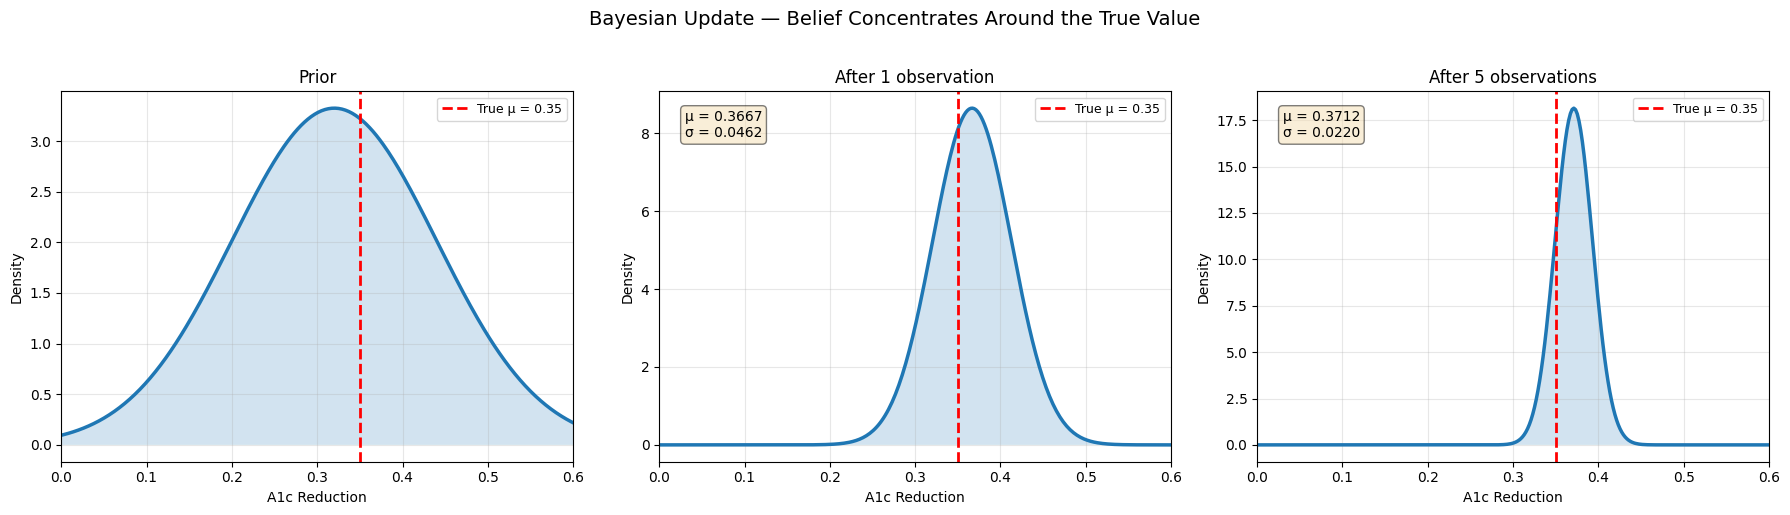

In [22]:
demo_state = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)
mu_true_metformin = 0.35  # valor "verdadeiro" fixado para esta demonstração

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range = np.linspace(0.0, 0.6, 300)

observations = []
titles = ['Prior', 'After 1 observation', 'After 5 observations']
plot_at = [0, 1, 5]  # captura snapshots nesses passos específicos
plot_idx = 0

for trial in range(6):
    if trial in plot_at:
        ax = axes[plot_idx]
        y = norm.pdf(x_range, demo_state.mu[0], demo_state.sigma[0])
        ax.plot(x_range, y, linewidth=2.5)
        ax.fill_between(x_range, y, alpha=0.2)
        ax.axvline(mu_true_metformin, color='red', linestyle='--', linewidth=2,
                   label=f'True μ = {mu_true_metformin}')
        ax.set(title=titles[plot_idx], xlabel='A1c Reduction', ylabel='Density', xlim=(0, 0.6))
        ax.legend(fontsize=9)
        if trial > 0:
            # exibe os valores atuais de μ e σ diretamente no gráfico
            ax.text(0.05, 0.95, f'μ = {demo_state.mu[0]:.4f}\nσ = {demo_state.sigma[0]:.4f}',
                    transform=ax.transAxes, va='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.grid(alpha=0.3)
        plot_idx += 1

    if trial < 5:
        # gera uma observação ruidosa e atualiza a crença sobre a Metformina
        W = mu_true_metformin + np.random.normal(0, sigma_W)
        observations.append(W)
        demo_state.update(0, W)

plt.suptitle('Bayesian Update — Belief Concentrates Around the True Value', fontsize=14, y=1.02)
plt.tight_layout()


## Simulator

To evaluate policies we simulate two levels of randomness:

1. The truth: $\mu_x \sim \mathcal{N}(\bar{\mu}_x^0, (\bar{\sigma}_x^0)^2)$ — true drug effect for this patient
2. Observations: $W^{n+1} \sim \mathcal{N}(\mu_x, (\sigma^W)^2)$ — noisy measurement

In [23]:
class DiabetesSimulator:
    """Generates truth μ_x and noisy observations W = μ_x + ε."""

    def __init__(self, mu_prior, sigma_prior, sigma_W, rng=None):
        self.rng = rng or np.random.RandomState()
        self.sigma_W = sigma_W
        # sorteia o efeito real de cada droga a partir da distribuição populacional
        # esses valores são desconhecidos pelo médico — só o simulador os conhece
        self.mu_true = np.array([
            self.rng.normal(mu_prior[i], sigma_prior[i])
            for i in range(len(mu_prior))
        ])

    def observe(self, x):
        # retorna a medição do exame — valor real mais um ruído de medição
        return self.mu_true[x] + self.rng.normal(0, self.sigma_W)


sim = DiabetesSimulator(mu_prior, sigma_prior, sigma_W, rng=np.random.RandomState(123))
best_drug = np.argmax(sim.mu_true)

print("True values μ_x (unknown to the doctor):")
for i in range(n_drugs):
    marker = " ← best" if i == best_drug else ""
    print(f"  {drug_names[i]:25s}  {sim.mu_true[i]:.4f}{marker}")

print(f"\nThree observations of Metformin (true μ = {sim.mu_true[0]:.4f}):")
for _ in range(3):
    W = sim.observe(0)
    print(f"  W = {W:.4f}  (noise = {W - sim.mu_true[0]:+.4f})")


True values μ_x (unknown to the doctor):
  Metformin                  0.1897
  Sensitizers                0.3698 ← best
  Secretagogues              0.3481
  Alpha-glucosidase Inh.     0.0341
  Peptide Analogs            0.1464

Three observations of Metformin (true μ = 0.1897):
  W = 0.2723  (noise = +0.0826)
  W = 0.0684  (noise = -0.1213)
  W = 0.1683  (noise = -0.0214)


## Decision Policies

All policies follow $x^n = \arg\max_{x} [\text{estimate} + \text{exploration bonus}]$ with different bonus terms:

**Greedy:** $X^{Greedy}(S^n) = \arg\max_{x} \bar{\mu}_x^n$ — no exploration.

**UCB:** $X^{UCB}(S^n | \theta) = \arg\max_{x} \left( \bar{\mu}_x^n + \theta \sqrt{\frac{\log n}{N_x^n}} \right)$ — bonus grows when a drug is under-tested.

**IE:** $X^{IE}(S^n | \theta) = \arg\max_{x} \left( \bar{\mu}_x^n + \theta \cdot \bar{\sigma}_x^n \right)$ — bonus from belief uncertainty.

**Thompson Sampling:** Sample $\hat{\mu}_x^n \sim \mathcal{N}(\bar{\mu}_x^n, \theta \cdot \bar{\sigma}_x^n)$, then $X^{TS}(S^n) = \arg\max_{x} \hat{\mu}_x^n$ — explores via randomness.

In [24]:
def policy_greedy(state, rng=None):
    # sem exploração: sempre aposta na droga com maior média estimada
    return np.argmax(state.mu)


def policy_ucb(state, theta_ucb=1.0, rng=None):
    n = state.n_experiments
    scores = np.full(state.n_drugs, np.inf)  # drogas ainda não testadas têm prioridade máxima (∞)
    for x in range(state.n_drugs):
        if state.N_x[x] > 0 and n > 0:
            # bônus diminui conforme a droga é mais testada e cresce com o tempo total
            scores[x] = state.mu[x] + theta_ucb * np.sqrt(np.log(max(n, 1)) / state.N_x[x])
    return np.argmax(scores)


def policy_ie(state, theta_ie=1.0, rng=None):
    # bônus de exploração proporcional à incerteza — quanto mais incerta, mais atraente
    return np.argmax(state.mu + theta_ie * state.sigma)


def policy_thompson(state, theta_ts=1.0, rng=None):
    rng = rng or np.random.RandomState()
    # sorteia um "cenário" de cada droga e escolhe o melhor — exploração emerge naturalmente
    samples = np.array([rng.normal(state.mu[x], theta_ts * state.sigma[x])
                        for x in range(state.n_drugs)])
    return np.argmax(samples)


## Single Trajectory

Running each policy for one patient over 30 time steps to see their behavior.

In [25]:
def run_single_trajectory(policy_fn, mu_prior, sigma_prior, sigma_W, N, seed=42):
    rng = np.random.RandomState(seed)
    sim = DiabetesSimulator(mu_prior, sigma_prior, sigma_W, rng=rng)
    state = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)

    # registra tudo para análise posterior: decisões, observações, crenças e recompensas
    history = dict(decisions=[], observations=[], cumulative_reward=[],
                   mu_estimates=[state.mu.copy()], sigma_estimates=[state.sigma.copy()],
                   mu_true=sim.mu_true.copy())
    total = 0.0

    for _ in range(N):
        x = policy_fn(state, rng=rng)   # política escolhe a droga
        W = sim.observe(x)              # obtém observação ruidosa
        total += W                      # acumula a recompensa total
        state.update(x, W)             # atualiza a crença bayesiana

        history['decisions'].append(x)
        history['observations'].append(W)
        history['mu_estimates'].append(state.mu.copy())
        history['sigma_estimates'].append(state.sigma.copy())
        history['cumulative_reward'].append(total)

    return history


N_trials = 30

policies = {
    'Greedy': lambda s, rng=None: policy_greedy(s, rng=rng),
    'UCB (θ=0.5)': lambda s, rng=None: policy_ucb(s, theta_ucb=0.5, rng=rng),
    'IE (θ=1.5)': lambda s, rng=None: policy_ie(s, theta_ie=1.5, rng=rng),
    'Thompson (θ=1.0)': lambda s, rng=None: policy_thompson(s, theta_ts=1.0, rng=rng),
}

results = {name: run_single_trajectory(pol, mu_prior, sigma_prior, sigma_W, N_trials)
           for name, pol in policies.items()}


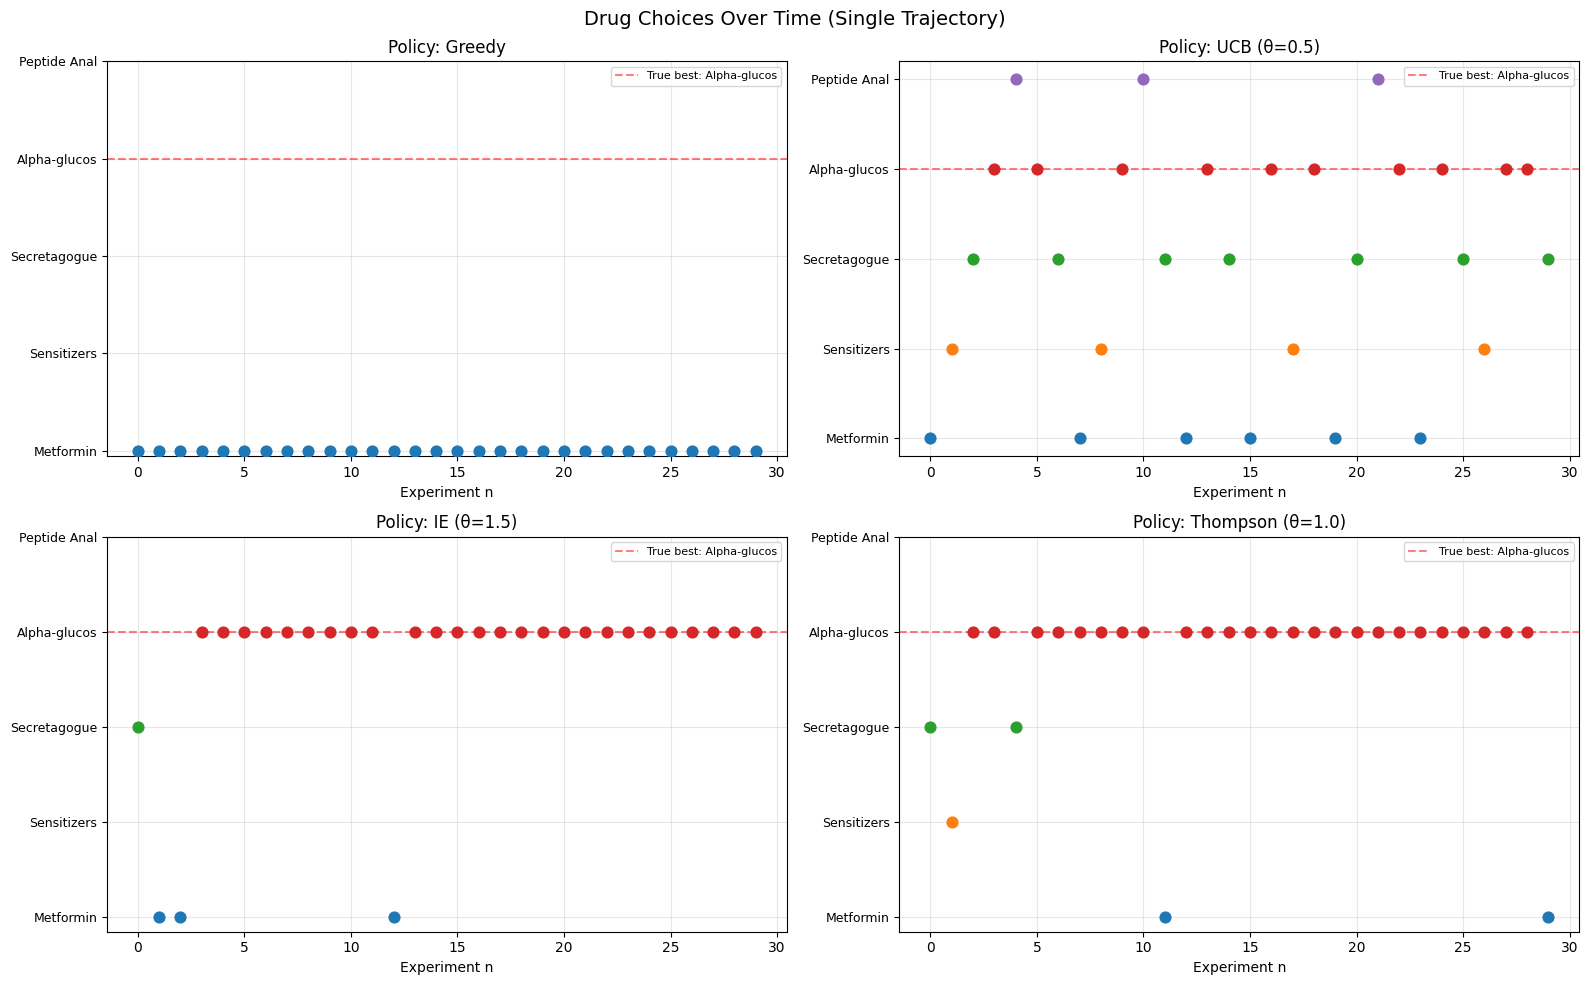

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (name, hist) in enumerate(results.items()):
    ax = axes.flat[idx]
    for t, d in enumerate(hist['decisions']):
        ax.scatter(t, d, color=f'C{d}', s=60, zorder=3)  # cada ponto = uma consulta médica

    ax.set_yticks(range(n_drugs))
    ax.set_yticklabels([n[:12] for n in drug_names], fontsize=9)
    ax.set_xlabel('Experiment n')
    ax.set_title(f'Policy: {name}')
    ax.grid(alpha=0.3)

    best = np.argmax(hist['mu_true'])  # droga mais eficaz nessa simulação
    ax.axhline(y=best, color='red', linestyle='--', alpha=0.5,
               label=f'True best: {drug_names[best][:12]}')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Drug Choices Over Time (Single Trajectory)', fontsize=14)
plt.tight_layout()


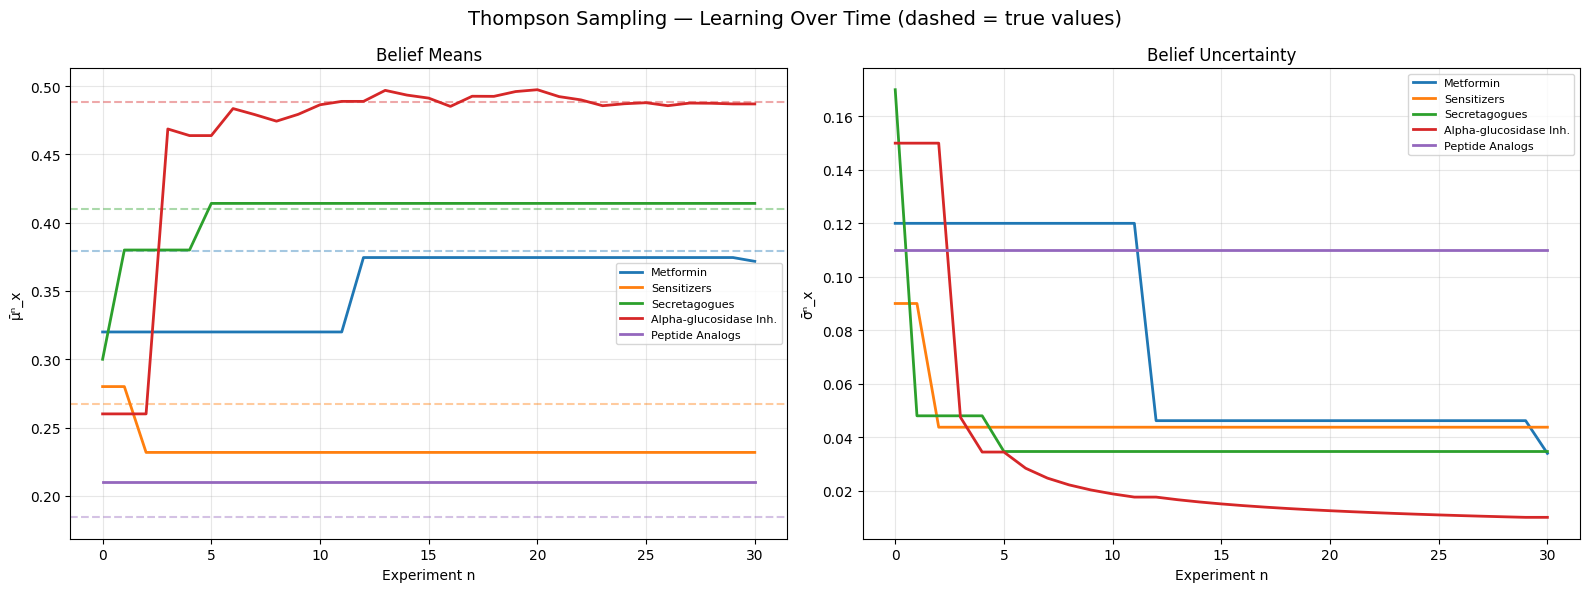

In [27]:
hist_ts = results['Thompson (θ=1.0)']
mu_est = np.array(hist_ts['mu_estimates'])      # série temporal das médias estimadas
sigma_est = np.array(hist_ts['sigma_estimates'])  # série temporal das incertezas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i in range(n_drugs):
    ax1.plot(mu_est[:, i], color=f'C{i}', label=drug_names[i], linewidth=2)
    ax1.axhline(y=hist_ts['mu_true'][i], color=f'C{i}', linestyle='--', alpha=0.4)  # valor real (oculto)
    ax2.plot(sigma_est[:, i], color=f'C{i}', label=drug_names[i], linewidth=2)

ax1.set(xlabel='Experiment n', ylabel='μ̄ⁿ_x', title='Belief Means')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.set(xlabel='Experiment n', ylabel='σ̄ⁿ_x', title='Belief Uncertainty')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Thompson Sampling — Learning Over Time (dashed = true values)', fontsize=14)
plt.tight_layout()


## Monte Carlo Evaluation

Comparing policies fairly requires many simulations across different patients:

$$F^\pi(S^0) \approx \frac{1}{K} \sum_{k=1}^{K} \sum_{n=0}^{N-1} W^{n+1}_{x^n}(\omega_k)$$

In [28]:
def evaluate_policy(policy_fn, mu_prior, sigma_prior, sigma_W, N, K, base_seed=0):
    total_rewards = []
    correct = 0
    cumulative_by_step = np.zeros(N)

    for k in range(K):
        rng = np.random.RandomState(base_seed + k)  # semente diferente por paciente (independência entre simulações)
        sim = DiabetesSimulator(mu_prior, sigma_prior, sigma_W, rng=rng)
        state = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)

        total = 0.0
        for n in range(N):
            x = policy_fn(state, rng=rng)
            W = sim.observe(x)
            total += W
            state.update(x, W)
            cumulative_by_step[n] += total  # soma para calcular a média depois

        total_rewards.append(total)
        # verifica se a política convergiu para a droga correta ao final
        if np.argmax(state.mu) == np.argmax(sim.mu_true):
            correct += 1

    return {
        'mean_reward': np.mean(total_rewards),
        'std_reward': np.std(total_rewards),
        'correct_rate': correct / K,
        'cumulative_by_step': cumulative_by_step / K,
    }


K = 2000  # 2000 pacientes simulados para uma estimativa estável

eval_results = {}
for name, pol in policies.items():
    eval_results[name] = evaluate_policy(pol, mu_prior, sigma_prior, sigma_W, N_trials, K)
    r = eval_results[name]
    print(f"{name:22s}  reward = {r['mean_reward']:.3f} ± {r['std_reward']:.3f}  "
          f"correct ID = {r['correct_rate']*100:.1f}%")


Greedy                  reward = 11.757 ± 2.741  correct ID = 59.2%
UCB (θ=0.5)             reward = 10.110 ± 2.413  correct ID = 91.4%
IE (θ=1.5)              reward = 12.507 ± 3.092  correct ID = 88.9%
Thompson (θ=1.0)        reward = 12.186 ± 2.960  correct ID = 90.8%


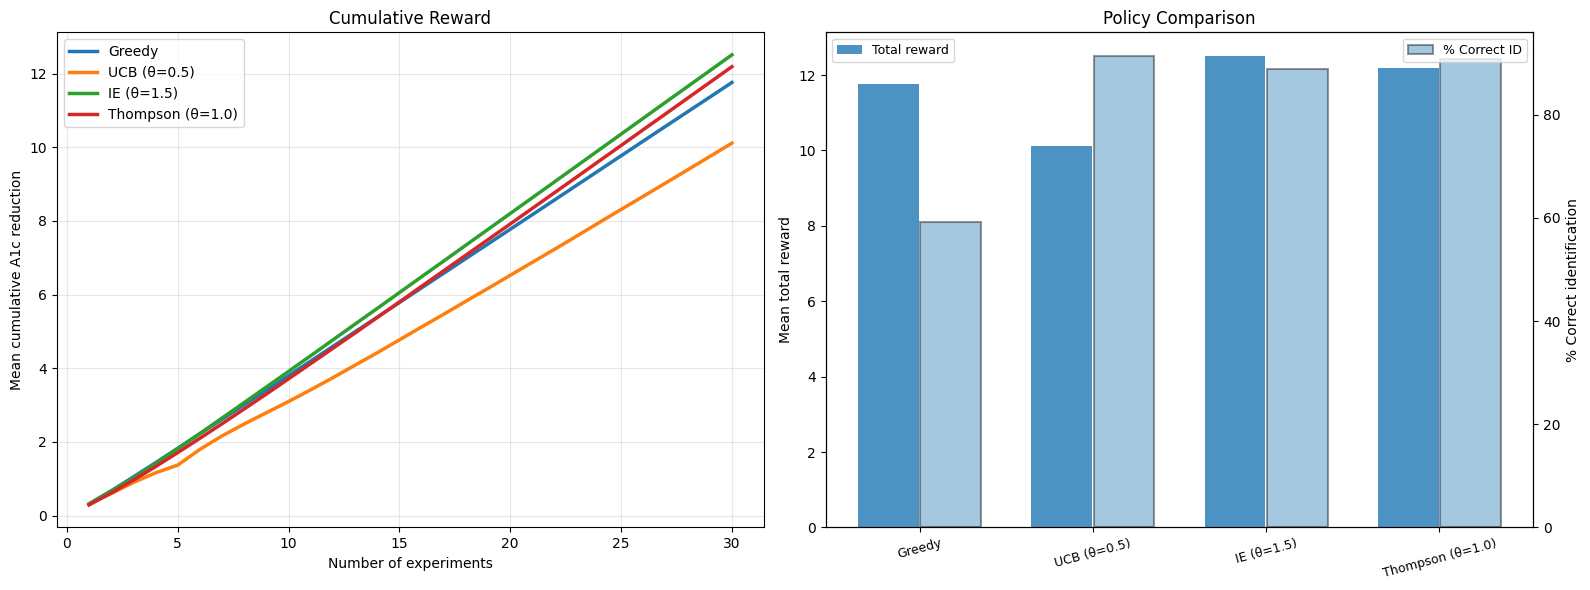

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

policy_names = list(eval_results.keys())
for idx, name in enumerate(policy_names):
    r = eval_results[name]
    ax1.plot(range(1, N_trials + 1), r['cumulative_by_step'], label=name, linewidth=2.5)

ax1.set(xlabel='Number of experiments', ylabel='Mean cumulative A1c reduction',
        title='Cumulative Reward')
ax1.legend()
ax1.grid(alpha=0.3)

means = [eval_results[n]['mean_reward'] for n in policy_names]
correct = [eval_results[n]['correct_rate'] * 100 for n in policy_names]
x_pos = np.arange(len(policy_names))

# barras deslocadas lado a lado para comparar duas métricas no mesmo gráfico
ax2.bar(x_pos - 0.18, means, 0.35, label='Total reward', alpha=0.8)
ax2_twin = ax2.twinx()  # eixo Y secundário para a porcentagem de acertos
ax2_twin.bar(x_pos + 0.18, correct, 0.35, label='% Correct ID',
             alpha=0.4, edgecolor='black', linewidth=1.5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(policy_names, rotation=15, fontsize=9)
ax2.set_ylabel('Mean total reward')
ax2_twin.set_ylabel('% Correct identification')
ax2.set_title('Policy Comparison')
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)
plt.tight_layout()


## Effect of the Exploration Parameter $\theta$

Low $\theta$ behaves like greedy. High $\theta$ over-explores. Sweeping $\theta^{IE}$ to find the sweet spot:

Best θ_IE = 1.50  (reward = 12.484)
θ = 0 (greedy) reward = 11.693


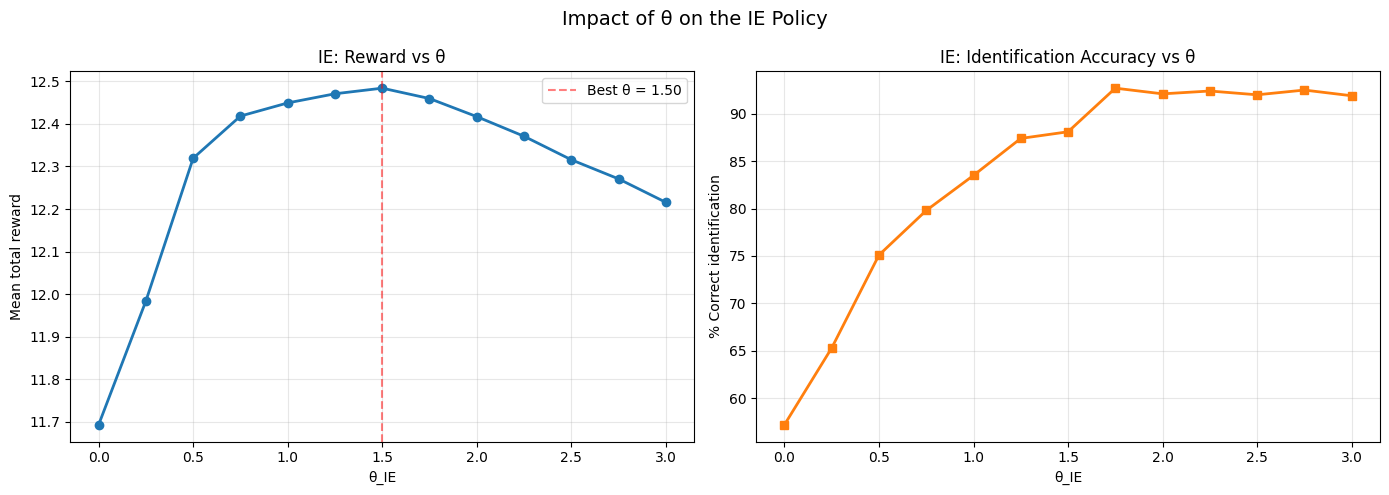

In [30]:
theta_values = np.arange(0.0, 3.1, 0.25)  # varredura de θ=0 (guloso puro) até θ=3 (muito explorador)
ie_rewards, ie_correct = [], []

for theta in theta_values:
    pol = lambda s, rng=None, t=theta: policy_ie(s, theta_ie=t, rng=rng)
    res = evaluate_policy(pol, mu_prior, sigma_prior, sigma_W, N_trials, 1000)
    ie_rewards.append(res['mean_reward'])
    ie_correct.append(res['correct_rate'] * 100)

best_idx = np.argmax(ie_rewards)  # índice do θ que maximiza a recompensa média

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(theta_values, ie_rewards, 'o-', linewidth=2, markersize=6)
ax1.axvline(theta_values[best_idx], color='red', linestyle='--', alpha=0.5,
            label=f'Best θ = {theta_values[best_idx]:.2f}')
ax1.set(xlabel='θ_IE', ylabel='Mean total reward', title='IE: Reward vs θ')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(theta_values, ie_correct, 's-', linewidth=2, markersize=6, color='tab:orange')
ax2.set(xlabel='θ_IE', ylabel='% Correct identification',
        title='IE: Identification Accuracy vs θ')
ax2.grid(alpha=0.3)

plt.suptitle('Impact of θ on the IE Policy', fontsize=14)
plt.tight_layout()

print(f"Best θ_IE = {theta_values[best_idx]:.2f}  (reward = {ie_rewards[best_idx]:.3f})")
print(f"θ = 0 (greedy) reward = {ie_rewards[0]:.3f}")


## Thompson Sampling Step by Step

Visualizing how Thompson Sampling draws samples from the belief and picks the highest.

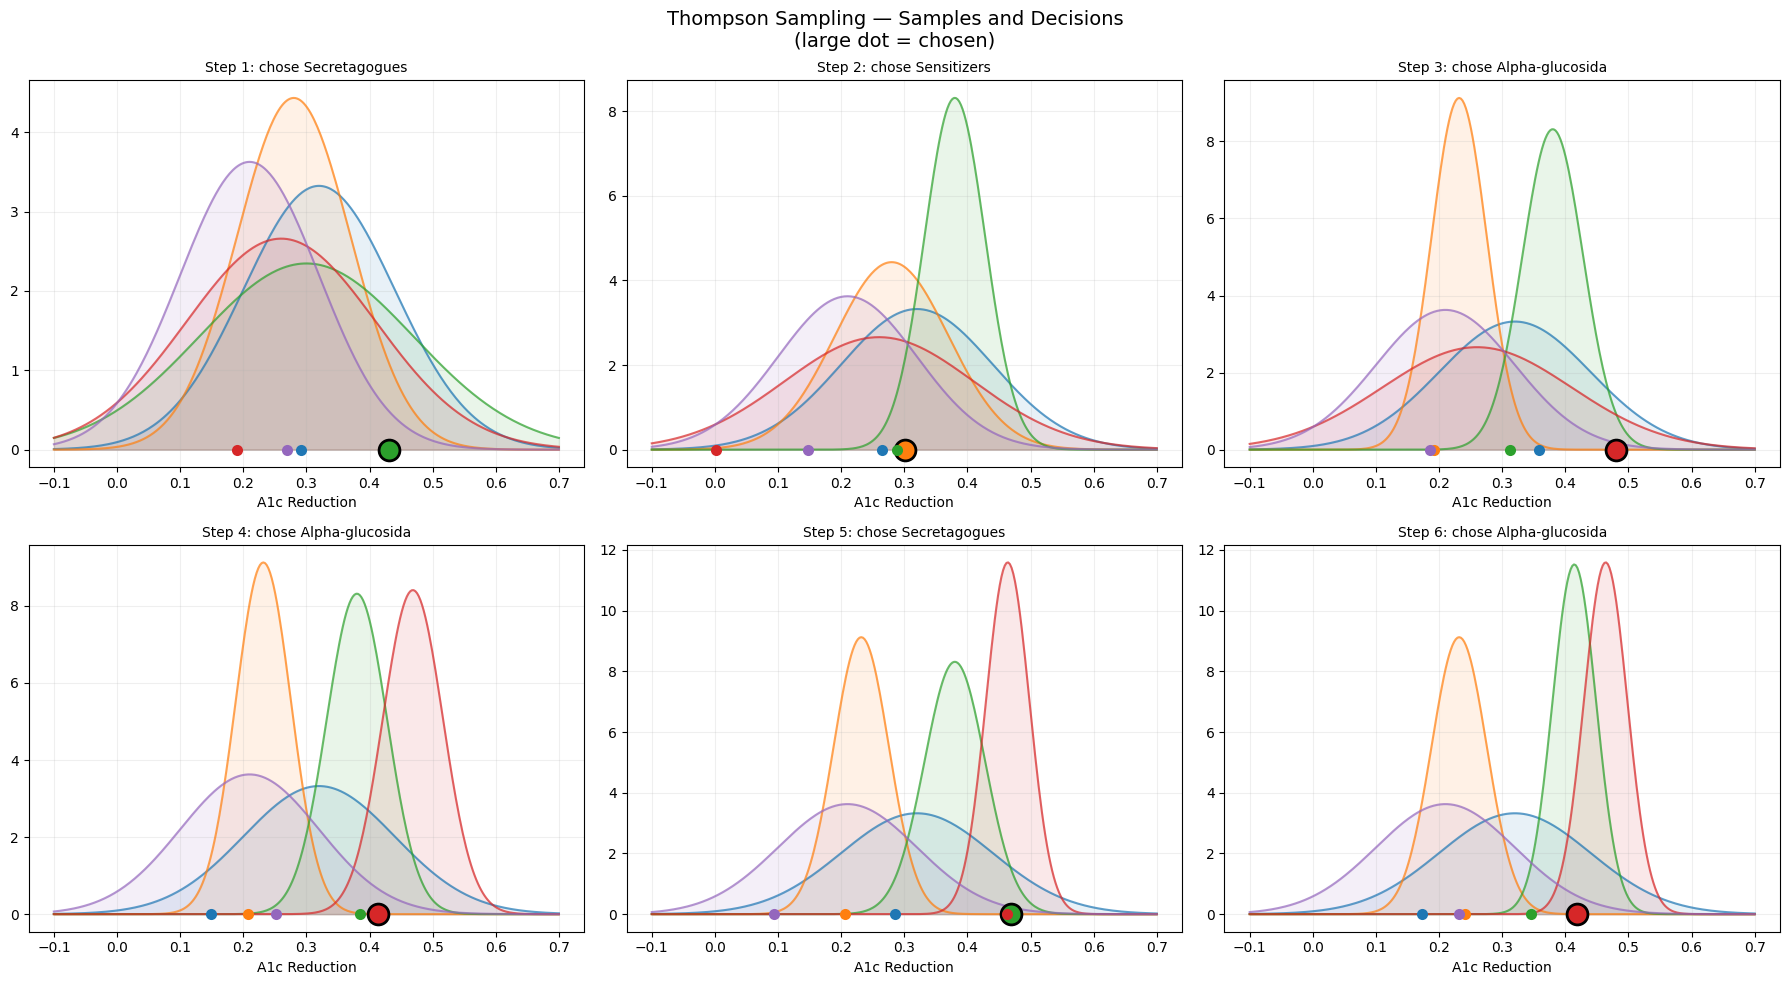

In [31]:
rng = np.random.RandomState(42)
sim = DiabetesSimulator(mu_prior, sigma_prior, sigma_W, rng=rng)
state = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
x_range = np.linspace(-0.1, 0.7, 300)

for step in range(6):
    ax = axes.flat[step]
    # sorteia um "candidato" de cada distribuição — Thompson Sampling em ação
    samples = np.array([rng.normal(state.mu[x], state.sigma[x]) for x in range(n_drugs)])
    chosen = np.argmax(samples)  # a droga com o maior sorteio é a escolhida

    for i in range(n_drugs):
        y = norm.pdf(x_range, state.mu[i], state.sigma[i])
        ax.plot(x_range, y, color=f'C{i}', linewidth=1.5, alpha=0.7)
        ax.fill_between(x_range, y, alpha=0.1, color=f'C{i}')

        # ponto maior com borda preta destaca visualmente a droga escolhida
        size = 15 if i == chosen else 8
        edge = 'black' if i == chosen else f'C{i}'
        ax.plot(samples[i], 0, 'o', markersize=size, color=f'C{i}',
                markeredgecolor=edge, markeredgewidth=2 if i == chosen else 0, zorder=5)

    ax.set_title(f'Step {step+1}: chose {drug_names[chosen][:15]}', fontsize=10)
    ax.set_xlabel('A1c Reduction')
    ax.grid(alpha=0.2)

    W = sim.observe(chosen)    # coleta o resultado do exame
    state.update(chosen, W)    # atualiza a crença — a distribuição da droga testada vai se afunilar

plt.suptitle('Thompson Sampling — Samples and Decisions\n(large dot = chosen)', fontsize=14)
plt.tight_layout()


## Estrutura Sequencial de Decisão

Todo problema de bandido multi-armado pode ser decomposto em quatro elementos que se repetem a cada passo $n$:

| Elemento | Notação | Papel |
|---|---|---|
| **Policy** | $x^n = \pi(S^n)$ | Decide qual droga testar dado o estado de crença atual |
| **Exog. Information** | $W^{n+1} = \mu_x + \varepsilon^{n+1}$ | Resultado do exame — aleatório, fora do controle da política |
| **Contribution** | $C = W^{n+1}$ | Redução de A1c observada — o que efetivamente ganhamos |
| **Transition** | $S^{n+1} = S^M(S^n, x^n, W^{n+1})$ | Atualização bayesiana — como o estado de crença evolui |

O loop abaixo implementa exatamente essa sequência de forma explícita.


In [32]:
# ================================================================
# POLICY — decide qual droga testar dado o estado de crença atual
# ================================================================
def sdp_policy(state, rng):
    """x^n = π(S^n): Thompson Sampling como política de decisão."""
    # sorteia um valor de cada crença e escolhe a droga com maior sorteio
    samples = np.array([rng.normal(state.mu[x], state.sigma[x]) for x in range(state.n_drugs)])
    return np.argmax(samples)


# ================================================================
# EXOGENOUS INFORMATION — o que o mundo revela após a decisão
# ================================================================
def sdp_exog_information(sim, x):
    """W^{n+1} = μ_x + ε^{n+1}: observação ruidosa do efeito real da droga."""
    # independe da política — é pura aleatoriedade do ambiente
    return sim.observe(x)


# ================================================================
# COST / CONTRIBUTION — o que ganhamos com essa decisão e observação
# ================================================================
def sdp_contribution(W):
    """C(S^n, x^n, W^{n+1}) = W^{n+1}: a própria redução de A1c é a recompensa."""
    return W


# ================================================================
# TRANSITION FUNCTION — como o estado de crença evolui
# ================================================================
def sdp_transition(state, x, W):
    """S^{n+1} = S^M(S^n, x^n, W^{n+1}): atualização bayesiana das Eqs. 4.1-4.2."""
    state.update(x, W)  # modifica μ̄_x e β_x in-place
    return state


# ================================================================
# Loop de decisão completo para um paciente (10 consultas)
# ================================================================
rng_sdp = np.random.RandomState(99)
sim_sdp = DiabetesSimulator(mu_prior, sigma_prior, sigma_W, rng=rng_sdp)
state_sdp = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)
total_contribution = 0.0

print(f"{'n':>4}  {'POLICY: x^n':25s}  {'EXOG: W^{n+1}':>13}  {'CONTRIB.':>10}  {'CUM. REWARD':>12}")
print("-" * 72)

for n in range(10):
    x     = sdp_policy(state_sdp, rng_sdp)              # 1. POLICY
    W     = sdp_exog_information(sim_sdp, x)             # 2. EXOGENOUS INFORMATION
    c     = sdp_contribution(W)                          # 3. CONTRIBUTION
    state_sdp = sdp_transition(state_sdp, x, W)          # 4. TRANSITION
    total_contribution += c

    print(f"{n+1:>4}  {drug_names[x]:25s}  {W:13.4f}  {c:10.4f}  {total_contribution:12.4f}")

print(f"\nDroga com maior crença ao final: {drug_names[np.argmax(state_sdp.mu)]}")
print(f"Droga realmente melhor:          {drug_names[np.argmax(sim_sdp.mu_true)]}")


   n  POLICY: x^n                EXOG: W^{n+1}    CONTRIB.   CUM. REWARD
------------------------------------------------------------------------
   1  Secretagogues                     0.3398      0.3398        0.3398
   2  Metformin                         0.3471      0.3471        0.6869
   3  Secretagogues                     0.3054      0.3054        0.9922
   4  Metformin                         0.3090      0.3090        1.3012
   5  Alpha-glucosidase Inh.            0.4836      0.4836        1.7848
   6  Alpha-glucosidase Inh.            0.5445      0.5445        2.3293
   7  Alpha-glucosidase Inh.            0.4187      0.4187        2.7480
   8  Alpha-glucosidase Inh.            0.4784      0.4784        3.2264
   9  Peptide Analogs                   0.2340      0.2340        3.4604
  10  Alpha-glucosidase Inh.            0.4527      0.4527        3.9131

Droga com maior crença ao final: Alpha-glucosidase Inh.
Droga realmente melhor:          Sensitizers


## Non-Stationary Version

In the original model, each drug's true effect (`mu_true`) is fixed for the patient. Here we relax that assumption: the effect drifts over time following a **random walk** with standard deviation `sigma_drift` per visit.

This requires two changes:

1. **Simulator**: `mu_true[x]` drifts at every observation
2. **Belief**: before each update, a **Kalman prediction step** injects process uncertainty - the belief "ages" between visits, preventing the doctor from over-trusting stale data

$$\sigma_x^{pred} = \sqrt{(\sigma_x^n)^2 + \sigma_{drift}^2} \qquad \Leftrightarrow \qquad \beta_x^{pred} = \frac{1}{1/\beta_x^n + \sigma_{drift}^2}$$

The key consequence: `sigma` never reaches zero - the doctor must keep exploring even after many visits.


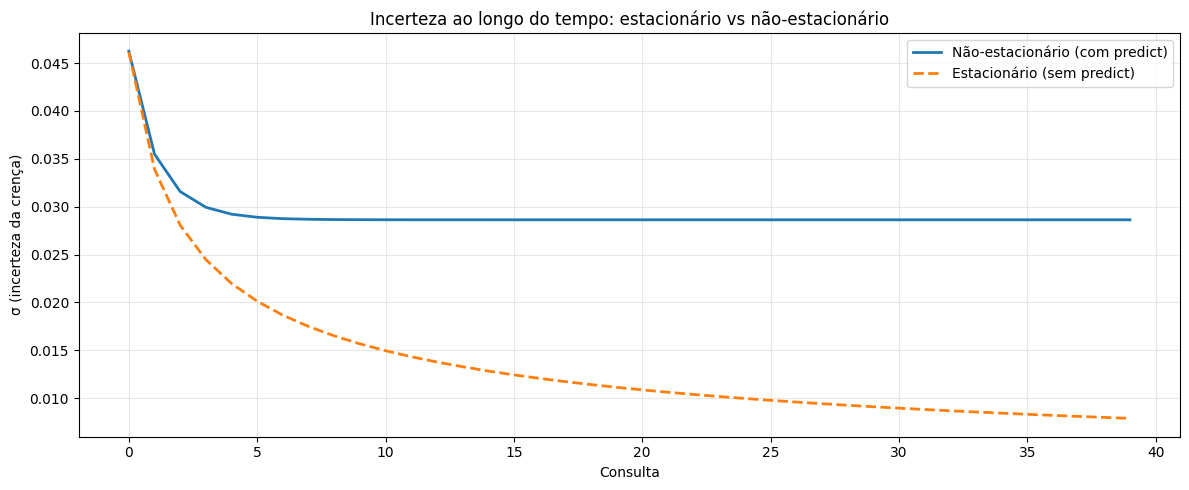

In [ ]:
class NonStationarySimulator:
    """Like DiabetesSimulator, but mu_true drifts at every observation (random walk)."""

    def __init__(self, mu_prior, sigma_prior, sigma_W, sigma_drift, rng=None):
        self.rng = rng or np.random.RandomState()
        self.sigma_W = sigma_W
        self.sigma_drift = sigma_drift
        # draw the initial true effect of each drug from the population distribution
        self.mu_true = np.array([
            self.rng.normal(mu_prior[i], sigma_prior[i])
            for i in range(len(mu_prior))
        ])

    def observe(self, x):
        # patient biology shifts slightly each visit - only for the tested drug
        self.mu_true[x] += self.rng.normal(0, self.sigma_drift)
        return self.mu_true[x] + self.rng.normal(0, self.sigma_W)


class NonStationaryBeliefState(BayesianBeliefState):
    """Extends BayesianBeliefState with a predict() step to handle world drift."""

    def __init__(self, mu_prior, sigma_prior, sigma_W, sigma_drift):
        super().__init__(mu_prior, sigma_prior, sigma_W)
        self.sigma_drift = sigma_drift

    def predict(self, x):
        """Kalman prediction step: injects process uncertainty before the update.

        Equivalent to saying: 'since the last visit for this drug, the world may
        have shifted a bit - so I am slightly less confident about it.'
        """
        # current variance + drift variance = new post-prediction variance
        variance_pred = (1.0 / self.beta[x]) + self.sigma_drift ** 2
        self.beta[x] = 1.0 / variance_pred  # beta drops - we become less certain

    def update(self, x, W):
        # first predict (age the belief), then incorporate the new observation
        self.predict(x)
        super().update(x, W)


sigma_drift = 0.02  # drift per visit - small but persistent

# quick demo: shows how sigma behaves over 40 visits
rng_demo = np.random.RandomState(7)
sim_ns = NonStationarySimulator(mu_prior, sigma_prior, sigma_W, sigma_drift, rng=rng_demo)
state_ns = NonStationaryBeliefState(mu_prior, sigma_prior, sigma_W, sigma_drift)
state_s  = BayesianBeliefState(mu_prior, sigma_prior, sigma_W)  # stationary for comparison

sigma_ns_track, sigma_s_track = [], []

for _ in range(40):
    # always test drug 0 to isolate the effect on a single drug
    W_ns = sim_ns.observe(0)
    state_ns.update(0, W_ns)
    sigma_ns_track.append(state_ns.sigma[0])

    W_s = sim_ns.mu_true[0] + rng_demo.normal(0, sigma_W)  # equivalent stationary observation
    state_s.update(0, W_s)
    sigma_s_track.append(state_s.sigma[0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sigma_ns_track, label='Non-stationary (with predict)', linewidth=2)
ax.plot(sigma_s_track,  label='Stationary (without predict)',  linewidth=2, linestyle='--')
ax.set(xlabel='Visit', ylabel='sigma (belief uncertainty)',
       title='Uncertainty over time: stationary vs non-stationary')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


### Policy Comparison in the Non-Stationary Environment

We now evaluate the same policies as before, but using the drifting simulator. The expectation is that exploratory policies (Thompson, IE) perform relatively better than Greedy, which stops exploring early and gets stuck with a drug whose effect may have degraded.


In [ ]:
def evaluate_policy_ns(policy_fn, mu_prior, sigma_prior, sigma_W, sigma_drift, N, K, base_seed=0):
    """Same as evaluate_policy, but uses non-stationary simulator and belief state."""
    total_rewards = []
    cumulative_by_step = np.zeros(N)

    for k in range(K):
        rng = np.random.RandomState(base_seed + k)
        sim   = NonStationarySimulator(mu_prior, sigma_prior, sigma_W, sigma_drift, rng=rng)
        state = NonStationaryBeliefState(mu_prior, sigma_prior, sigma_W, sigma_drift)

        total = 0.0
        for n in range(N):
            x = policy_fn(state, rng=rng)
            W = sim.observe(x)
            total += W
            state.update(x, W)
            cumulative_by_step[n] += total  # accumulate to compute the average later

        total_rewards.append(total)

    return {
        'mean_reward': np.mean(total_rewards),
        'std_reward': np.std(total_rewards),
        'cumulative_by_step': cumulative_by_step / K,
    }


N_trials_ns = 60   # more visits to let the drift effect become visible
K_ns = 2000

eval_ns = {}
for name, pol in policies.items():
    eval_ns[name] = evaluate_policy_ns(pol, mu_prior, sigma_prior, sigma_W,
                                       sigma_drift, N_trials_ns, K_ns)
    r = eval_ns[name]
    print(f"{name:22s}  reward = {r['mean_reward']:.3f} +/- {r['std_reward']:.3f}")


Greedy                  reward = 25.579 ± 6.688
UCB (θ=0.5)             reward = 22.339 ± 5.922
IE (θ=1.5)              reward = 26.584 ± 7.277
Thompson (θ=1.0)        reward = 25.910 ± 6.975



Recompensa média — comparação direta:
Política                  Estacionário    Não-estacionário         Δ
----------------------------------------------------------------------
Greedy                          23.712              25.579    +1.867
UCB (θ=0.5)                     21.293              22.339    +1.046
IE (θ=1.5)                      25.448              26.584    +1.136
Thompson (θ=1.0)                25.105              25.910    +0.804


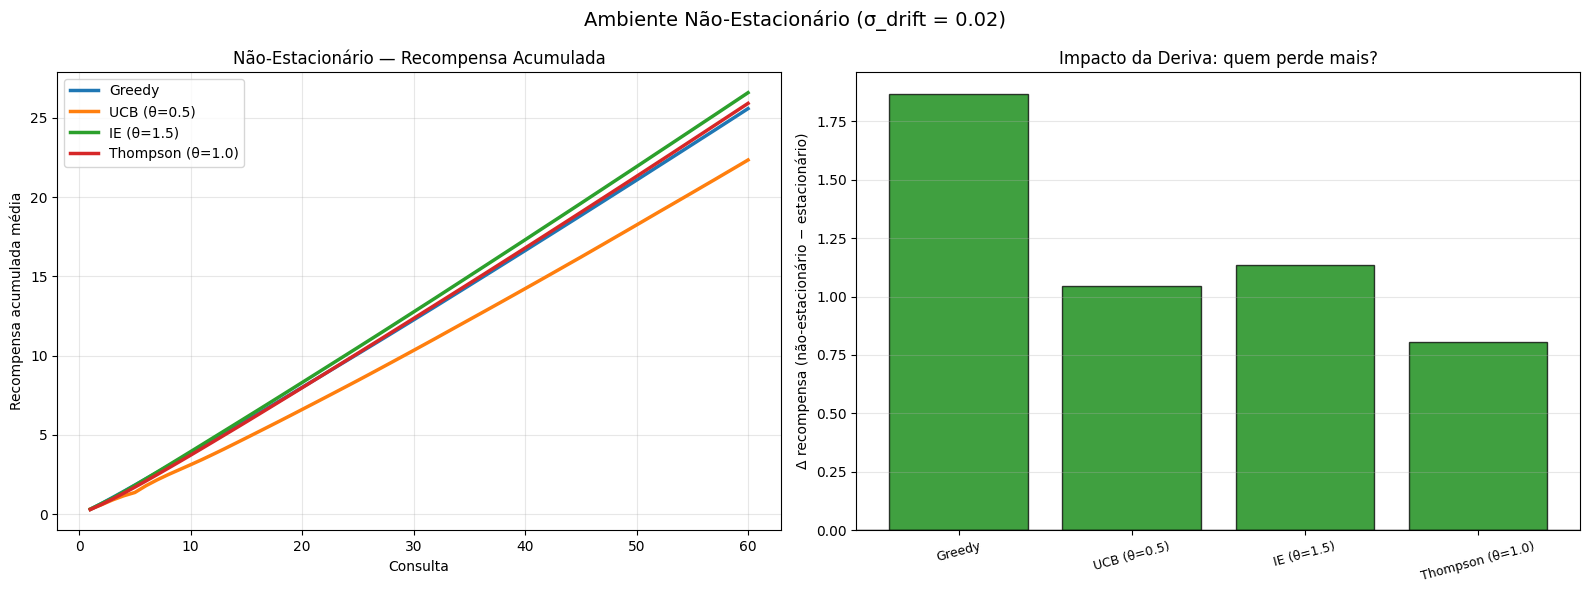

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- left: cumulative reward in the non-stationary environment ---
for name in eval_ns:
    ax1.plot(range(1, N_trials_ns + 1), eval_ns[name]['cumulative_by_step'],
             label=name, linewidth=2.5)
ax1.set(xlabel='Visit', ylabel='Mean cumulative reward',
        title='Non-Stationary - Cumulative Reward')
ax1.legend()
ax1.grid(alpha=0.3)

# --- right: reward difference vs stationary (same N) ---
# re-evaluate stationary with N_trials_ns visits for a fair comparison
eval_s_long = {}
for name, pol in policies.items():
    eval_s_long[name] = evaluate_policy(pol, mu_prior, sigma_prior, sigma_W,
                                        N_trials_ns, K_ns)

x_pos = np.arange(len(policies))
policy_names_list = list(policies.keys())
diff = [eval_ns[n]['mean_reward'] - eval_s_long[n]['mean_reward'] for n in policy_names_list]

colors = ['green' if d >= 0 else 'red' for d in diff]
ax2.bar(x_pos, diff, color=colors, alpha=0.75, edgecolor='black', linewidth=1)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(policy_names_list, rotation=15, fontsize=9)
ax2.set_ylabel('Delta reward (non-stationary minus stationary)')
ax2.set_title('Impact of Drift: who loses the most?')
ax2.grid(alpha=0.3, axis='y')

plt.suptitle(f'Non-Stationary Environment (sigma_drift = {sigma_drift})', fontsize=14)
plt.tight_layout()

print("\nMean reward - direct comparison:")
print(f"{'Policy':22s}  {'Stationary':>14}  {'Non-stationary':>18}  {'Delta':>8}")
print("-" * 70)
for name in policy_names_list:
    s  = eval_s_long[name]['mean_reward']
    ns = eval_ns[name]['mean_reward']
    print(f"{name:22s}  {s:14.3f}  {ns:18.3f}  {ns-s:+8.3f}")
